 Реализация метода условного градиента (Франк-Вульфа) и сравнение с субградиентным методом и проксимальным методом на примере задачи LASSO (L1-регуляризация)

Истинная L1-норма коэффициентов: 514.65
R-ограничение для Frank-Wolfe: 411.72

Запуск Субградиентного метода с alpha_0=0.5...
Субградиентный метод: конечное значение объективной функции = 332.7643
Субградиентный метод: L1-норма x = 736.42, Количество ненулевых элементов = 100

Запуск Проксимального градиентного метода с step_size=0.3231...
Проксимальный градиентный метод: конечное значение объективной функции = 51.4217
Проксимальный градиентный метод: L1-норма x = 513.68, Количество ненулевых элементов = 10

Запуск Метода Франка-Вульфа (для задачи с ограничением L1-шаром R=411.72)...
Метод Франка-Вульфа: конечное значение объективной функции (MSE) = 580.0674
Метод Франка-Вульфа: L1-норма x = 411.70, Количество ненулевых элементов = 8
Примечание: для FW объективная функция - это только MSE, L1-норма - это ограничение.


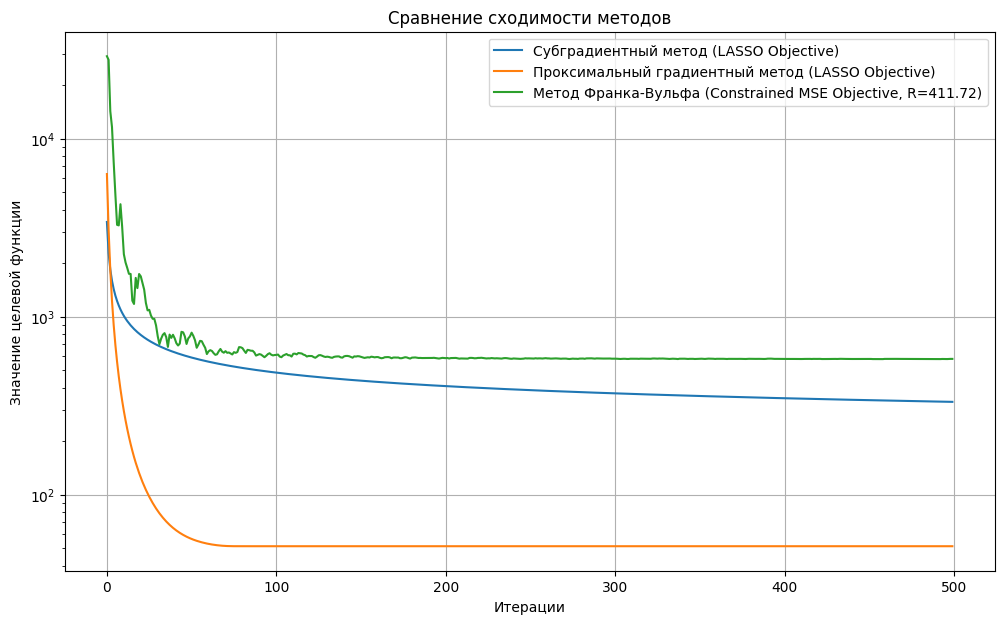


--- Сравнение разреженности решений ---
Истинные коэффициенты: 10 ненулевых
Субградиентный метод: 100 ненулевых
Проксимальный градиентный метод: 10 ненулевых
Метод Франка-Вульфа: 8 ненулевых


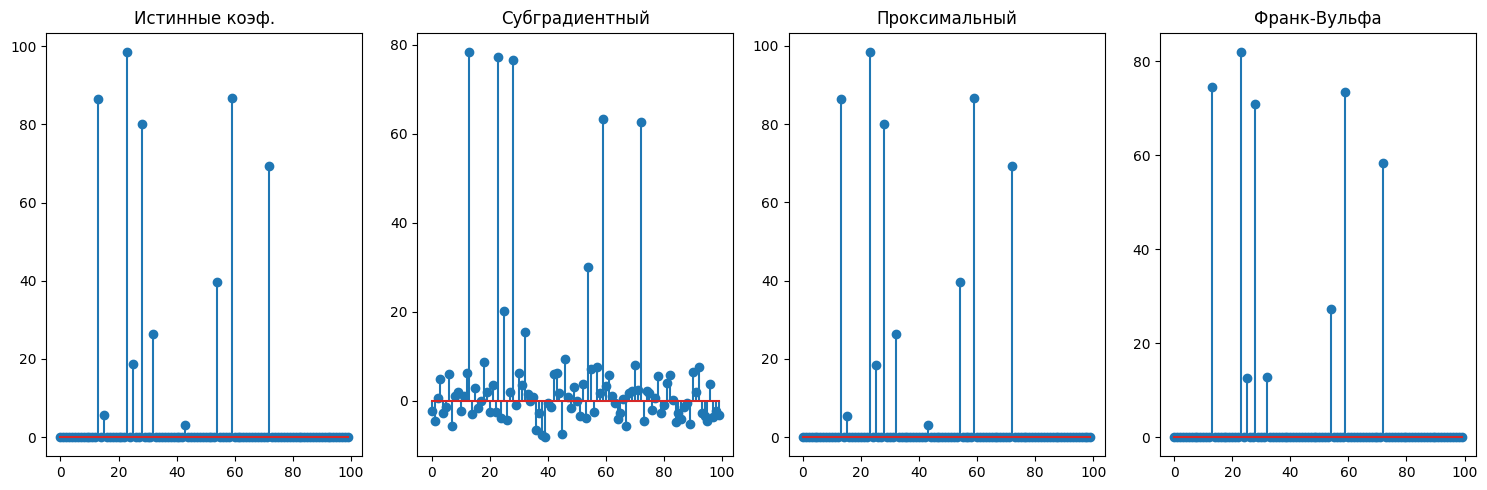

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from scipy.linalg import norm as np_norm # Using scipy's norm for spectral norm

# --- 0. Вспомогательные функции (остаются без изменений) ---

def objective_lasso(x, A, b, lambda_val, n_samples):
    return (1.0 / (2 * n_samples)) * np_norm(A @ x - b)**2 + lambda_val * np_norm(x, 1)

def objective_constrained_least_squares(x, A, b, n_samples):
    return (1.0 / (2 * n_samples)) * np_norm(A @ x - b)**2

def gradient_smooth_part(x, A, b, n_samples):
    return (1.0 / n_samples) * A.T @ (A @ x - b)

def subgradient_lasso(x, A, b, lambda_val, n_samples):
    grad_smooth = gradient_smooth_part(x, A, b, n_samples)
    subgrad_l1 = lambda_val * np.sign(x)
    return grad_smooth + subgrad_l1

def soft_thresholding(v, tau):
    return np.sign(v) * np.maximum(0, np.abs(v) - tau)

# --- 1. Субградиентный метод (без изменений) ---

def subgradient_method(A, b, lambda_val, n_samples, num_iterations, initial_learning_rate):
    d = A.shape[1]
    x = np.zeros(d)
    objective_history = []

    for k in range(1, num_iterations + 1):
        grad = subgradient_lasso(x, A, b, lambda_val, n_samples)
        alpha_k = initial_learning_rate / k
        x = x - alpha_k * grad
        objective_history.append(objective_lasso(x, A, b, lambda_val, n_samples))

    return x, objective_history

# --- 2. Проксимальный градиентный метод (без изменений) ---

def proximal_gradient_method(A, b, lambda_val, n_samples, num_iterations, step_size):
    d = A.shape[1]
    x = np.zeros(d)
    objective_history = []

    for k in range(num_iterations):
        grad_smooth = gradient_smooth_part(x, A, b, n_samples)
        v = x - step_size * grad_smooth
        x = soft_thresholding(v, step_size * lambda_val)
        objective_history.append(objective_lasso(x, A, b, lambda_val, n_samples))

    return x, objective_history

# --- 3. Метод Франка-Вульфа (без изменений) ---

def lmo_l1_ball(grad, R_constraint):
    j_star = np.argmax(np.abs(grad))
    s_k = np.zeros_like(grad)
    s_k[j_star] = -R_constraint * np.sign(grad[j_star])
    return s_k

def frank_wolfe_constrained_lasso(A, b, n_samples, R_constraint, num_iterations):
    d = A.shape[1]
    x = np.zeros(d)
    objective_history = []

    for k in range(1, num_iterations + 1):
        grad = gradient_smooth_part(x, A, b, n_samples)
        s_k = lmo_l1_ball(grad, R_constraint)
        gamma_k = 2.0 / (k + 2)
        x = (1 - gamma_k) * x + gamma_k * s_k
        objective_history.append(objective_constrained_least_squares(x, A, b, n_samples))

    return x, objective_history

# --- Генерация данных и сравнение ---

if __name__ == "__main__":
    # Параметры данных
    n_samples = 200
    n_features = 100
    n_informative = 10
    noise = 0.1
    random_state = 42

    # Генерация синтетических данных LASSO
    A, b, coef_true = make_regression(n_samples=n_samples, n_features=n_features,
                                     n_informative=n_informative, noise=noise,
                                     coef=True, random_state=random_state)

    # Параметры алгоритмов
    lambda_val = 0.1
    num_iterations = 500

    R_constraint = np_norm(coef_true, 1) * 0.8

    print(f"Истинная L1-норма коэффициентов: {np_norm(coef_true, 1):.2f}")
    print(f"R-ограничение для Frank-Wolfe: {R_constraint:.2f}")

    # --- Субградиентный метод ---
    initial_learning_rate_sg = 0.5
    print(f"\nЗапуск Субградиентного метода с alpha_0={initial_learning_rate_sg}...")
    x_sg, hist_sg = subgradient_method(A, b, lambda_val, n_samples, num_iterations, initial_learning_rate_sg)
    print(f"Субградиентный метод: конечное значение объективной функции = {hist_sg[-1]:.4f}")
    print(f"Субградиентный метод: L1-норма x = {np_norm(x_sg, 1):.2f}, Количество ненулевых элементов = {np.sum(x_sg != 0):d}")


    # --- Проксимальный градиентный метод ---
    lipschitz_constant_f1 = np_norm(A.T @ A, 2) / n_samples
    step_size_pg = 1.0 / lipschitz_constant_f1 * 0.9
    print(f"\nЗапуск Проксимального градиентного метода с step_size={step_size_pg:.4f}...")
    x_pg, hist_pg = proximal_gradient_method(A, b, lambda_val, n_samples, num_iterations, step_size_pg)
    print(f"Проксимальный градиентный метод: конечное значение объективной функции = {hist_pg[-1]:.4f}")
    print(f"Проксимальный градиентный метод: L1-норма x = {np_norm(x_pg, 1):.2f}, Количество ненулевых элементов = {np.sum(x_pg != 0):d}")

    # --- Метод Франка-Вульфа ---
    print(f"\nЗапуск Метода Франка-Вульфа (для задачи с ограничением L1-шаром R={R_constraint:.2f})...")
    x_fw, hist_fw = frank_wolfe_constrained_lasso(A, b, n_samples, R_constraint, num_iterations)
    print(f"Метод Франка-Вульфа: конечное значение объективной функции (MSE) = {hist_fw[-1]:.4f}")
    print(f"Метод Франка-Вульфа: L1-норма x = {np_norm(x_fw, 1):.2f}, Количество ненулевых элементов = {np.sum(x_fw != 0):d}")
    print(f"Примечание: для FW объективная функция - это только MSE, L1-норма - это ограничение.")


    # --- Визуализация сходимости ---
    plt.figure(figsize=(12, 7))
    plt.plot(hist_sg, label='Субградиентный метод (LASSO Objective)')
    plt.plot(hist_pg, label='Проксимальный градиентный метод (LASSO Objective)')
    plt.plot(hist_fw, label=f'Метод Франка-Вульфа (Constrained MSE Objective, R={R_constraint:.2f})')

    plt.title('Сравнение сходимости методов')
    plt.xlabel('Итерации')
    plt.ylabel('Значение целевой функции')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Сравнение разреженности решений ---
    print("\n--- Сравнение разреженности решений ---")
    print(f"Истинные коэффициенты: {np.sum(coef_true != 0)} ненулевых")
    print(f"Субградиентный метод: {np.sum(x_sg != 0)} ненулевых")
    print(f"Проксимальный градиентный метод: {np.sum(x_pg != 0)} ненулевых")
    print(f"Метод Франка-Вульфа: {np.sum(x_fw != 0)} ненулевых")

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.stem(coef_true) # Удалено use_line_collection=True
    plt.title('Истинные коэф.')
    plt.subplot(1, 4, 2)
    plt.stem(x_sg) # Удалено use_line_collection=True
    plt.title('Субградиентный')
    plt.subplot(1, 4, 3)
    plt.stem(x_pg) # Удалено use_line_collection=True
    plt.title('Проксимальный')
    plt.subplot(1, 4, 4)
    plt.stem(x_fw) # Удалено use_line_collection=True
    plt.title('Франк-Вульфа')
    plt.tight_layout()
    plt.show()
